In [1]:
from pathlib import Path
import skimage as ski
import numpy as np
from imageio.v3 import immeta
import matplotlib.pyplot as plt

%matplotlib widget

## Exploratory analysis

Histogram equalization enhances cell contrast but not NPs. Also increases noise a lot

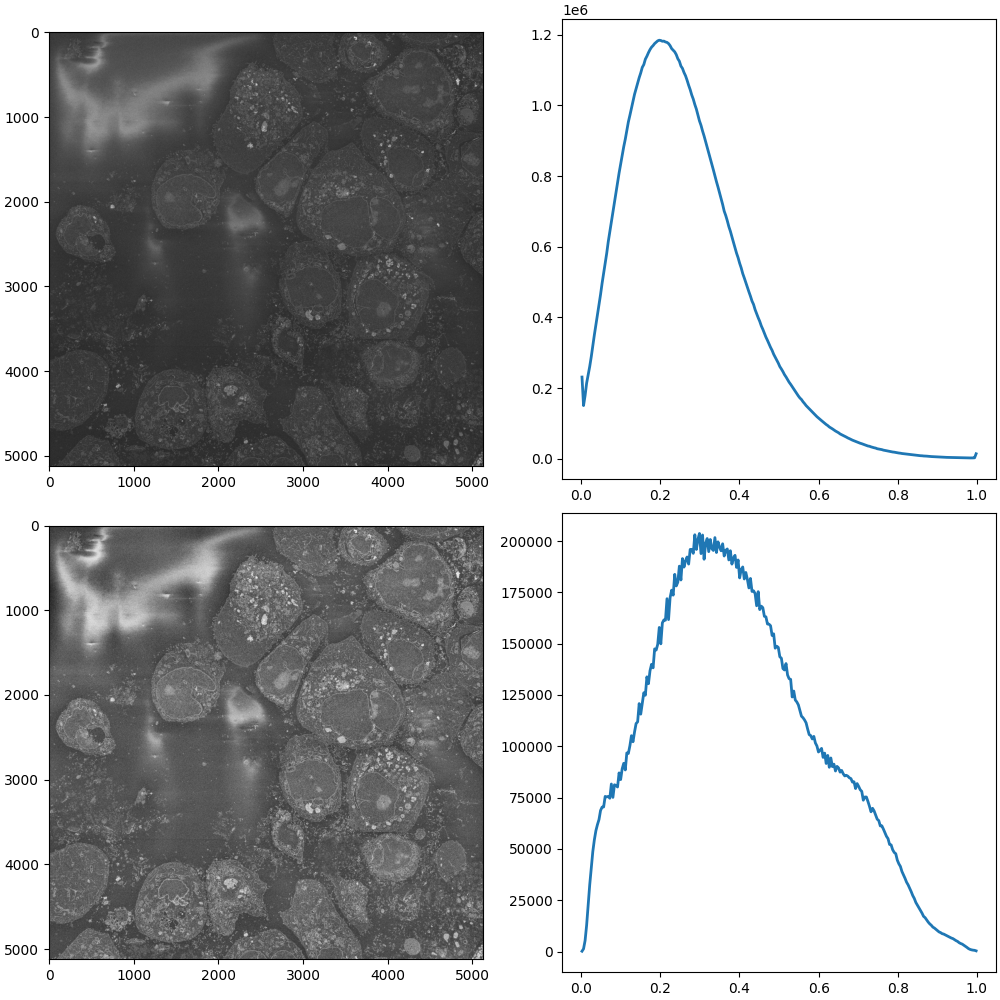

In [4]:
image_path = Path("../data/raw/Au_01-vol_01/Au_01-vol_01-z_0174.tif")

image = ski.io.imread(image_path)
image = ski.util.img_as_float(image)
image_ds = ski.transform.downscale_local_mean(image, (2, 2))
hist, hist_centers = ski.exposure.histogram(image)

image_ds_equal = ski.exposure.equalize_adapthist(image_ds, kernel_size=int(image_ds.shape[0] / 10))
hist_eq, hist_centers_eq = ski.exposure.histogram(image_ds_equal)

fig, ax = plt.subplots(2, 2, figsize=(10, 10), layout='constrained')
ax[0, 0].imshow(image_ds, cmap='gray')
ax[0, 1].plot(hist_centers, hist, lw=2)

ax[1, 0].imshow(image_ds_equal, cmap='gray')
ax[1, 1].plot(hist_centers_eq, hist_eq, lw=2)